In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from gensim.models import Word2Vec
import numpy as np
import re
import pandas as pd


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
import string

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


In [15]:
# === Download necessary NLTK data ===
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")

FINE_TUNED_DIR = '../../../pretained_or_finetune-models'
REVIEWS_DATASET_DIR = '../../dataset'
UTILS_DIR = '../../utils'
NLTK_DATA_PATH = f"{FINE_TUNED_DIR}/nltk_data"

nltk.data.path.append(NLTK_DATA_PATH)

# === Constants ===
STOPWORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()
CONST_VECTOR_SIZE = 50
CONST_DIM_WINDOWS = 3

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


In [41]:
def advanced_clean_text(text):
    if not isinstance(text, str):
        return "other"  # Handle non-string values safely
    
    # Define domain-specific stopwords
    custom_stopwords = {'point', 'points', 'interest', 'landmark', 'landmarks', 'site', 'sites'}  # Remove generic tourism terms
    
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^a-z\s]', '', text)  # Remove special characters
    text = re.sub(r'\b(u|ur|b4)\b', 'you', text)  # Replace common abbreviations

    words = text.split()  # ✅ Fix: Use split() instead of word_tokenize()
    words = [LEMMATIZER.lemmatize(word) for word in words if word not in STOPWORDS]
    words = [word for word in words if word not in custom_stopwords and word not in string.punctuation]  # Remove tourism-related stopwords

    return ' '.join(words)  

In [42]:
combined_details_df = pd.read_csv("../data/combined_details.csv")

In [43]:
combined_details_df['tags']

0                      History Museums, Specialty Museums
1                                            Bars & Clubs
2                                Sacred & Religious Sites
3                                              Boat Tours
4                                         Bodies of Water
                              ...                        
1761                                              Beaches
1762                                              Bridges
1763    Sacred & Religious Sites, Architectural Buildings
1764                                              Beaches
1765                                             Lookouts
Name: tags, Length: 1766, dtype: object

In [44]:
combined_details_df['tags'] = combined_details_df['tags'].fillna("").astype(str)
combined_details_df['tags'] = combined_details_df['tags'].apply(advanced_clean_text)
combined_details_df['tags'].replace("", "other", inplace=True)

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_50545/3197724261.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_details_df['tags'].replace("", "other", inplace=True)


In [45]:
combined_details_df['tags']

0               history museum specialty museum
1                                      bar club
2                              sacred religious
3                                     boat tour
4                                    body water
                         ...                   
1761                                      beach
1762                                     bridge
1763    sacred religious architectural building
1764                                      beach
1765                                    lookout
Name: tags, Length: 1766, dtype: object

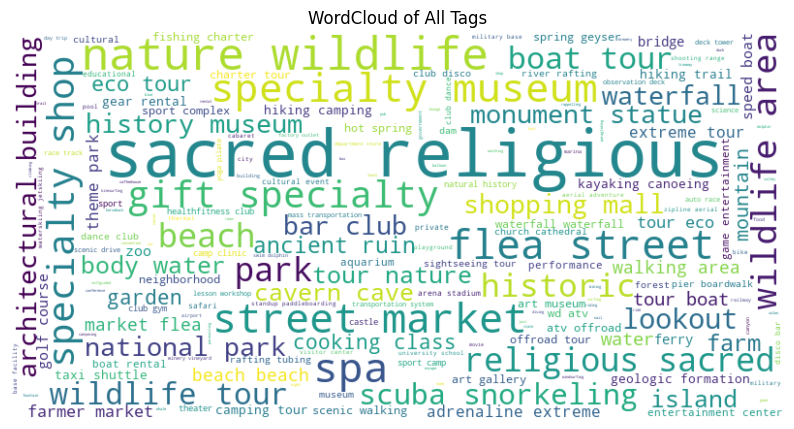

In [47]:
all_text = " ".join(combined_details_df['tags'].dropna())
# สร้าง WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# แสดง WordCloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of All Tags")
plt.show()

## Experiment - [TF-IDF + K-MEAN + LDA]

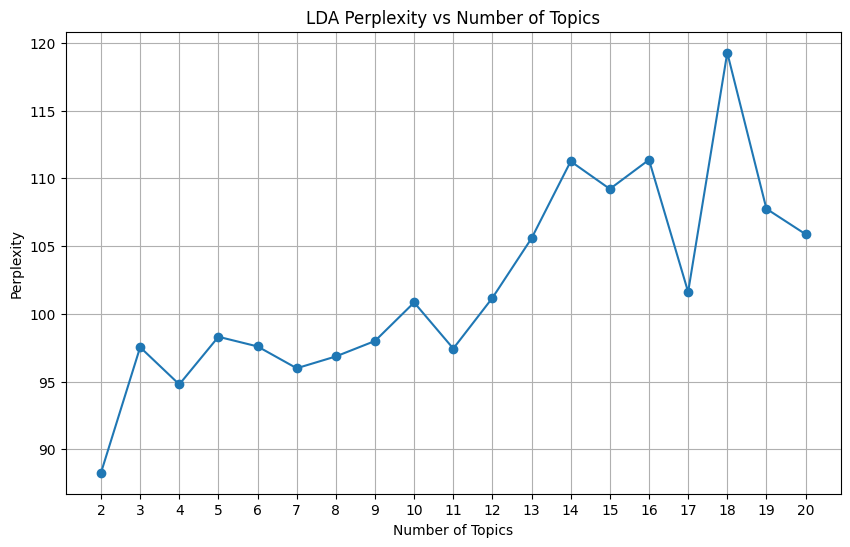

In [49]:
perplexities = []
topic_range = range(2, 21)  # กำหนดช่วงของจำนวนหัวข้อ (2 ถึง 20)

for n_topics in topic_range:
    lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=42)
    lda_model.fit(X)
    perplexities.append(lda_model.perplexity(X))

# การ Visualize ค่า Perplexity
plt.figure(figsize=(10, 6))
plt.plot(topic_range, perplexities, marker='o')
plt.title('LDA Perplexity vs Number of Topics')
plt.xlabel('Number of Topics')
plt.ylabel('Perplexity')
plt.xticks(topic_range)
plt.grid()
plt.show()

In [60]:
N_CLUSTER = 8

# ตรวจสอบและแทนค่าที่เป็น NaN ในคอลัมน์ 'tags'
combined_details_df['tags'] = combined_details_df['tags'].fillna('')
combined_details_df['tags'].replace("", "other", inplace=True)

# แปลงข้อความใน 'tags' ให้เป็นเมทริกซ์ TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(combined_details_df['tags'])

# สร้างโมเดล LDA เพื่อหา topics
lda_model = LatentDirichletAllocation(n_components=N_CLUSTER, random_state=42)  # กำหนด 5 topics
lda_model.fit(X)

# ดึง top keywords ในแต่ละ topic
def print_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

print_topics(lda_model, vectorizer.get_feature_names_out(), n_top_words=10)

# กำหนดกลุ่มให้แต่ละสถานที่
combined_details_df['topic'] = lda_model.transform(X).argmax(axis=1)



/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_50545/175247613.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_details_df['tags'].replace("", "other", inplace=True)


Topic 0:
spa island garden ferry dam boardwalk pier science school university
Topic 1:
sacred religious beach flea street market taxi shuttle government food
Topic 2:
park nature wildlife area tour national theme golf course eco
Topic 3:
other lookout sport complex theater church cathedral kayaking canoeing cabaret
Topic 4:
cavern cave mountain tour farmer walking trail performance market hiking
Topic 5:
waterfall monument statue building architectural bridge neighborhood aquarium forest hot
Topic 6:
specialty museum shop gift historic farm history water body ruin
Topic 7:
club mall shopping bar boat tour scuba snorkeling class cooking


In [61]:
def get_topic_words(lda_model, feature_names, n_top_words=11):
    topic_words = []
    for topic_idx, topic in enumerate(lda_model.components_):
        words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topic_words.append(" ".join(words))
    return topic_words

# Generate topic words from LDA model
topic_words = get_topic_words(lda_model, vectorizer.get_feature_names_out(), n_top_words=20)

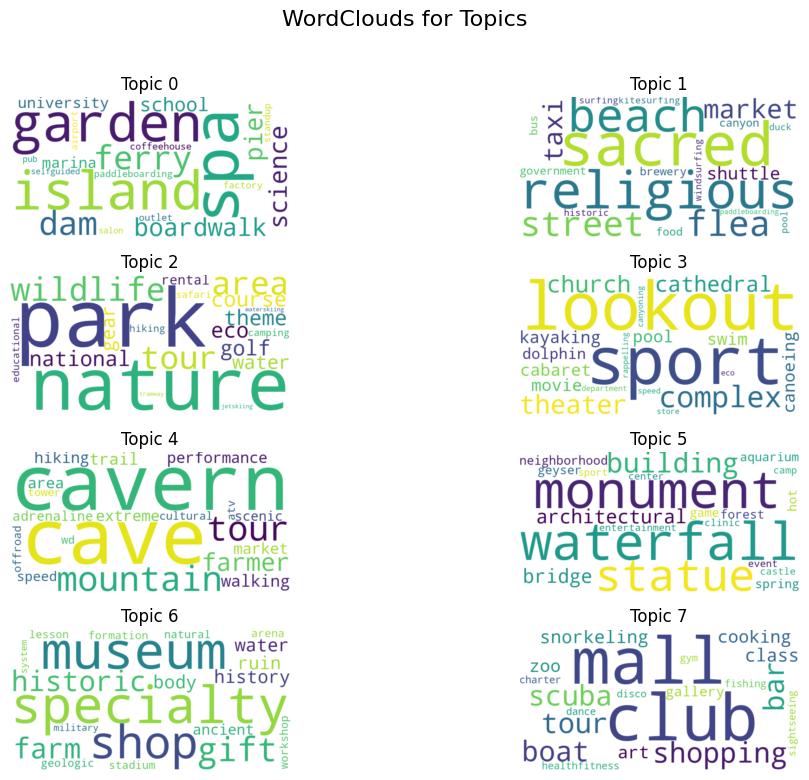

In [66]:
def plot_wordclouds_in_grid(topic_words, n_rows=4, n_cols=2):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
    fig.suptitle("WordClouds for Topics", fontsize=16, y=0.97)  # Adjust title position

    for idx, words in enumerate(topic_words):
        if idx < n_rows * n_cols:
            row, col = divmod(idx, n_cols)
            wordcloud = WordCloud(width=800, height=400, background_color='white').generate(words)
            axes[row, col].imshow(wordcloud, interpolation='bilinear')
            axes[row, col].axis('off')
            axes[row, col].set_title(f"Topic {idx}", fontsize=12)
        else:
            axes[row, col].axis('off')  # Turn off any extra axes

    # Adjust the layout
    plt.subplots_adjust(hspace=0.4, wspace=0.3)  # Reduce vertical (hspace) and horizontal (wspace) gaps
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout and leave space for title
    plt.show()

plot_wordclouds_in_grid(topic_words, n_rows=4, n_cols=2)

In [54]:
combined_details_df[['name', 'tags', 'topic']]

,name,tags,topic
0,House of Opium,history museum specialty museum,6
1,Opium Bar,bar club,7
2,Wat Phra That Doi Saket,sacred religious,1
3,Mae Ping River Cruise,boat tour,7
4,Pai River,body water,6
...,...,...,...
1761,Chao Lao Beach,beach,1
1762,Chao Lao Fish Bridge,bridge,5
1763,Wat Burapa Temple,sacred religious architectural building,5
1764,Kung Wiman Beach,beach,1
